In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

print("Libraries imported successfully!")

Libraries imported successfully!


In [33]:
data = {
    "Student_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 103],
    "Name": ["Akhila", "Anu", "Priya", "Rahul", "Sneha",
             "Kiran", "Divya", "Arjun", "Meena", "Ravi", "Priya"],
    "Department": ["CSE", "ECE", "CSE", "IT", "CSE",
                   "ECE", "IT", "CSE", "ECE", "IT", "CSE"],
    "Age": [21, 20, 21, 22, 20, 21, 22, 20, 21, 22, 21],
    "Marks": [85, 78, 92, 67, 88, np.nan, 76, 95, 81, 70, 92],
    "Attendance": [90, 85, 95, 75, 88, 80, np.nan, 96, 89, 72, 95]
}

df = pd.DataFrame(data)

# Save dataset
df.to_csv("student_performance.csv", index=False)

# Load dataset
df = pd.read_csv("student_performance.csv")

print("Dataset loaded successfully!")
display(df)

Dataset loaded successfully!


,Student_ID,Name,Department,Age,Marks,Attendance
0,101,Akhila,CSE,21,85.0,90.0
1,102,Anu,ECE,20,78.0,85.0
2,103,Priya,CSE,21,92.0,95.0
3,104,Rahul,IT,22,67.0,75.0
4,105,Sneha,CSE,20,88.0,88.0
5,106,Kiran,ECE,21,NaN,80.0
6,107,Divya,IT,22,76.0,NaN
7,108,Arjun,CSE,20,95.0,96.0
8,109,Meena,ECE,21,81.0,89.0
9,110,Ravi,IT,22,70.0,72.0


In [34]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove duplicate records
df = df.drop_duplicates()

# Fill missing Marks with average Marks
df["Marks"] = df["Marks"].fillna(df["Marks"].mean())

# Fill missing Attendance with average Attendance
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nCleaned Dataset:")
display(df)

Missing values before cleaning:
Student_ID    0
Name          0
Department    0
Age           0
Marks         1
Attendance    1
dtype: int64

Missing values after cleaning:
Student_ID    0
Name          0
Department    0
Age           0
Marks         0
Attendance    0
dtype: int64

Cleaned Dataset:


,Student_ID,Name,Department,Age,Marks,Attendance
0,101,Akhila,CSE,21,85.000000,90.000000
1,102,Anu,ECE,20,78.000000,85.000000
2,103,Priya,CSE,21,92.000000,95.000000
3,104,Rahul,IT,22,67.000000,75.000000
4,105,Sneha,CSE,20,88.000000,88.000000
5,106,Kiran,ECE,21,81.333333,80.000000
6,107,Divya,IT,22,76.000000,85.555556
7,108,Arjun,CSE,20,95.000000,96.000000
8,109,Meena,ECE,21,81.000000,89.000000
9,110,Ravi,IT,22,70.000000,72.000000


In [36]:
# Basic statistics
print("Average Marks:", round(df["Marks"].mean(), 2))
print("Highest Marks:", df["Marks"].max())
print("Lowest Marks:", df["Marks"].min())
print("Average Attendance:", round(df["Attendance"].mean(), 2))

# Department-wise average marks
department_average = df.groupby("Department")["Marks"].mean()

print("\nDepartment-wise Average Marks:")
print(department_average)

# Top student
top_student = df.loc[df["Marks"].idxmax()]

print("\nTop Performing Student:")
print("Name:", top_student["Name"])
print("Marks:", top_student["Marks"])

# Students who scored above 80
print("\nStudents scoring above 80:")
display(df[df["Marks"] > 80])

Average Marks: 81.33
Highest Marks: 95.0
Lowest Marks: 67.0
Average Attendance: 85.56

Department-wise Average Marks:
Department
CSE    90.000000
ECE    80.111111
IT     71.000000
Name: Marks, dtype: float64

Top Performing Student:
Name: Arjun
Marks: 95.0

Students scoring above 80:


,Student_ID,Name,Department,Age,Marks,Attendance
0,101,Akhila,CSE,21,85.000000,90.0
2,103,Priya,CSE,21,92.000000,95.0
4,105,Sneha,CSE,20,88.000000,88.0
5,106,Kiran,ECE,21,81.333333,80.0
7,108,Arjun,CSE,20,95.000000,96.0
8,109,Meena,ECE,21,81.000000,89.0


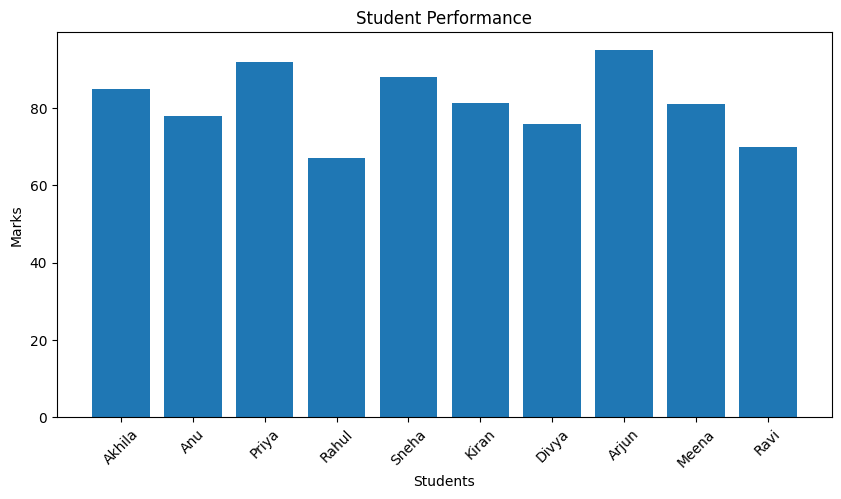

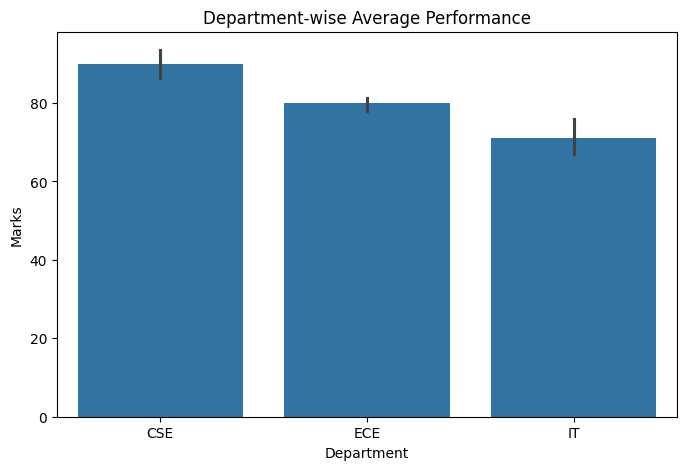

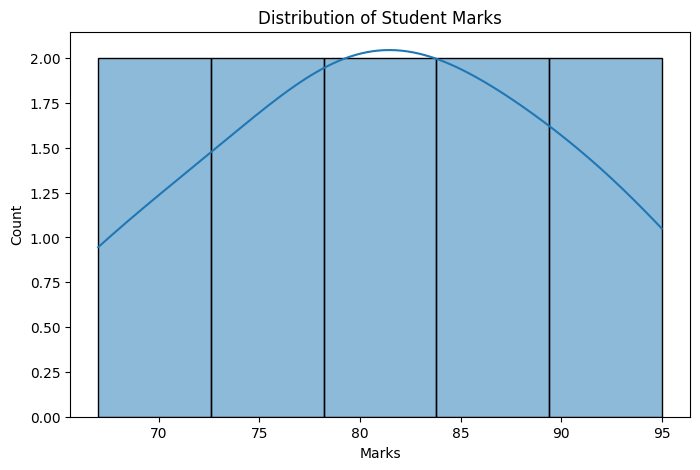

In [37]:
# Student Marks - Matplotlib
plt.figure(figsize=(10, 5))

plt.bar(df["Name"], df["Marks"])

plt.xlabel("Students")
plt.ylabel("Marks")
plt.title("Student Performance")

plt.xticks(rotation=45)
plt.show()


# Department-wise Marks - Seaborn
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="Department", y="Marks")

plt.title("Department-wise Average Performance")
plt.show()


# Marks Distribution
plt.figure(figsize=(8, 5))

sns.histplot(df["Marks"], kde=True)

plt.title("Distribution of Student Marks")
plt.xlabel("Marks")
plt.show()

In [38]:
url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)

print("HTTP Status Code:", response.status_code)

# Convert JSON response to Python data
api_data = response.json()

# Convert API data into DataFrame
api_df = pd.DataFrame(api_data)

print("\nAPI Data:")
display(api_df[["id", "name", "email"]])

HTTP Status Code: 200

API Data:


,id,name,email
0,1,Leanne Graham,Sincere@april.biz
1,2,Ervin Howell,Shanna@melissa.tv
2,3,Clementine Bauch,Nathan@yesenia.net
3,4,Patricia Lebsack,Julianne.OConner@kory.org
4,5,Chelsey Dietrich,Lucio_Hettinger@annie.ca
5,6,Mrs. Dennis Schulist,Karley_Dach@jasper.info
6,7,Kurtis Weissnat,Telly.Hoeger@billy.biz
7,8,Nicholas Runolfsdottir V,Sherwood@rosamond.me
8,9,Glenna Reichert,Chaim_McDermott@dana.io
9,10,Clementina DuBuque,Rey.Padberg@karina.biz


In [39]:
total_students = len(df)
average_marks = df["Marks"].mean()
highest_marks = df["Marks"].max()
lowest_marks = df["Marks"].min()
average_attendance = df["Attendance"].mean()

report = f"""
========================================
     STUDENT PERFORMANCE REPORT
========================================

Total Students       : {total_students}
Average Marks        : {average_marks:.2f}
Highest Marks        : {highest_marks:.2f}
Lowest Marks         : {lowest_marks:.2f}
Average Attendance   : {average_attendance:.2f}

Department-wise Average Marks:
{department_average.to_string()}

Top Performing Student:
Name  : {top_student["Name"]}
Marks : {top_student["Marks"]}

========================================
"""

print(report)


     STUDENT PERFORMANCE REPORT

Total Students       : 10
Average Marks        : 81.33
Highest Marks        : 95.00
Lowest Marks         : 67.00
Average Attendance   : 85.56

Department-wise Average Marks:
Department
CSE    90.000000
ECE    80.111111
IT     71.000000

Top Performing Student:
Name  : Arjun
Marks : 95.0




In [40]:
df.to_csv("cleaned_student_performance.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File name: cleaned_student_performance.csv")

Cleaned dataset saved successfully!
File name: cleaned_student_performance.csv
